# Домашнее задание 4
**Цель:** Реализовать симуляцию эпидемии по модели SI (Susceptible-Infected) на основе расписания авиарейсов, оценить влияние инфекционности вируса на скорость захвата сети, рассчитать топологические метрики графа аэропортов и выявить связь между структурой сети и скоростью заражения городов.

### Часть 1. EDA, препроцессинг и написание симуляции

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Загружаем датасет
df = pd.read_csv('2008.csv')
print(f"Формат исходных данных: {df.shape}")

# Оставляем только нужные колонки для оптимизации памяти и скорости
cols = ['Year', 'Month', 'DayofMonth', 'DepTime', 'ArrTime', 'Origin', 'Dest']
df = df[cols].dropna()

df['DepTime'] = df['DepTime'].astype(int)
df['ArrTime'] = df['ArrTime'].astype(int)

display(df.head())

Формат исходных данных: (7009728, 29)


,Year,Month,DayofMonth,DepTime,ArrTime,Origin,Dest
0,2008,1,3,2003,2211,IAD,TPA
1,2008,1,3,754,1002,IAD,TPA
2,2008,1,3,628,804,IND,BWI
3,2008,1,3,926,1054,IND,BWI
4,2008,1,3,1829,1959,IND,BWI


In [13]:
# Переводим дату и время вылета в часы с начала месяца
def to_absolute_hours(row):
    hours = row['DayofMonth'] * 24
    dep_time = int(row['DepTime'])
    hh = dep_time // 100
    mm = dep_time % 100
    return hours + hh + (mm / 60.0)

df['AbsDepTime'] = df.apply(to_absolute_hours, axis=1)

# Сортируем по времени
df = df.sort_values(by='AbsDepTime').reset_index(drop=True)

In [14]:
def run_si_simulation(flight_df, start_airport='ABE', p=0.5):
    """
    Симуляция одного прохода распространения инфекции.
    flight_df: отсортированный по времени датафрейм рейсов
    start_airport: код стартового аэропорта
    p: вероятность заражения
    """

    infected_airports = {start_airport}
    
    # Словарь результатов: ключ - время заражения, значение - название аэропорта
    infection_timeline = {0.0: start_airport}

    for row in flight_df.itertuples():
        origin = row.Origin
        dest = row.Dest
        dep_time = row.AbsDepTime

        if origin in infected_airports and dest not in infected_airports:
            if np.random.rand() < p:
                infected_airports.add(dest)
                infection_timeline[dep_time] = dest
                
    return infection_timeline

# Тестовый запуск
test_sim = run_si_simulation(df, start_airport='ABE', p=0.5)
print(f"Из {df['Origin'].nunique()} аэропортов заражено {len(test_sim)}")

Из 303 аэропортов заражено 199


### Часть 2. Влияние инфекционности болезни на скорость распространения

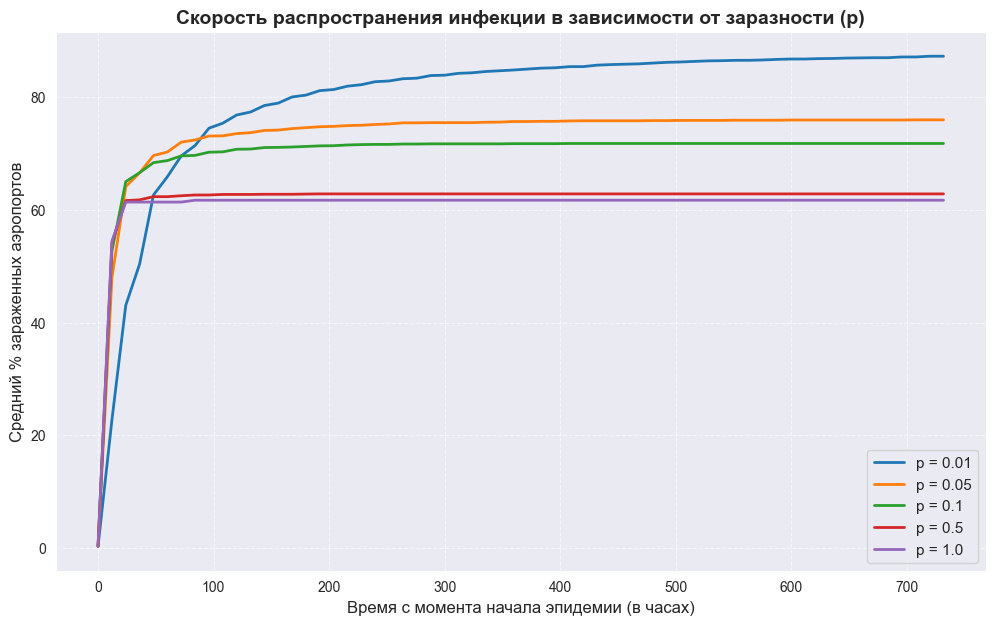

In [15]:
probabilities = [0.01, 0.05, 0.1, 0.5, 1.0]
n_simulations = 10
total_airports = df['Origin'].nunique()

max_time = df['AbsDepTime'].max()
time_steps = np.arange(df['AbsDepTime'].min(), max_time, 12)

plt.figure(figsize=(12, 7))

for p in probabilities:
    all_sim_curves = []
    
    for sim in range(n_simulations):
        sim_result = run_si_simulation(df, start_airport='ABE', p=p)
        times = sorted(sim_result.keys())
        infected_counts = []
        
        for t in time_steps:
            count = sum(1 for k in times if k <= t)
            pct = (count / total_airports) * 100
            infected_counts.append(pct)
            
        all_sim_curves.append(infected_counts)
        
    mean_curve = np.mean(all_sim_curves, axis=0)
    plt.plot(time_steps - time_steps[0], mean_curve, label=f'p = {p}', linewidth=2)

plt.title('Скорость распространения инфекции в зависимости от заразности (p)', fontsize=14, fontweight='bold')
plt.xlabel('Время с момента начала эпидемии (в часах)', fontsize=12)
plt.ylabel('Средний % зараженных аэропортов', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Часть 3. Метрики сети (NetworkX) и предсказание уязвимости

In [16]:
total_flights = len(df)

df['Pair'] = df.apply(lambda r: tuple(sorted([r['Origin'], r['Dest']])), axis=1)
pair_counts = df['Pair'].value_counts()

# Строим ненаправленный граф
G = nx.Graph()

for pair, count in pair_counts.items():
    u, v = pair
    weight = count / total_flights
    G.add_edge(u, v, weight=weight)

print(f"Узлов (аэропортов): {G.number_of_nodes()}, Ребер (маршрутов): {G.number_of_edges()}")

Узлов (аэропортов): 303, Ребер (маршрутов): 2683


In [17]:
n_runs = 50
p_val = 0.5
airport_list = list(G.nodes())

airport_infection_times = {node: [] for node in airport_list}

print("Запуск 50 симуляций для сбора медианного времени...")
for run in range(n_runs):
    sim_res = run_si_simulation(df, start_airport='ABE', p=p_val)
    
    for node in airport_list:
        node_time = [t for t, name in sim_res.items() if name == node]
        if node_time:
            airport_infection_times[node].append(node_time[0])
        else:
            airport_infection_times[node].append(max_time)

median_times = {}
for node in airport_list:
    median_times[node] = np.median(airport_infection_times[node])

print("Медианное время заражения рассчитано")

Запуск 50 симуляций для сбора медианного времени...
Медианное время заражения рассчитано


In [18]:
clustering_coeff = nx.clustering(G)
degree_dict = dict(G.degree())
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

analysis_data = []
for node in airport_list:
    analysis_data.append({
        'Airport': node,
        'Median_Infection_Time': median_times[node],
        'Clustering_Coeff': clustering_coeff[node],
        'Degree': degree_dict[node],
        'Betweenness': betweenness_cent[node]
    })

df_metrics = pd.DataFrame(analysis_data)
display(df_metrics.head())

,Airport,Median_Infection_Time,Clustering_Coeff,Degree,Betweenness
0,LAX,768.0,0.338866,89,0.037925
1,SFO,768.0,0.348240,70,0.032849
2,HNL,768.0,0.768116,24,0.000000
3,OGG,32.0,0.784314,18,0.007019
4,LAS,768.0,0.370452,91,0.033366


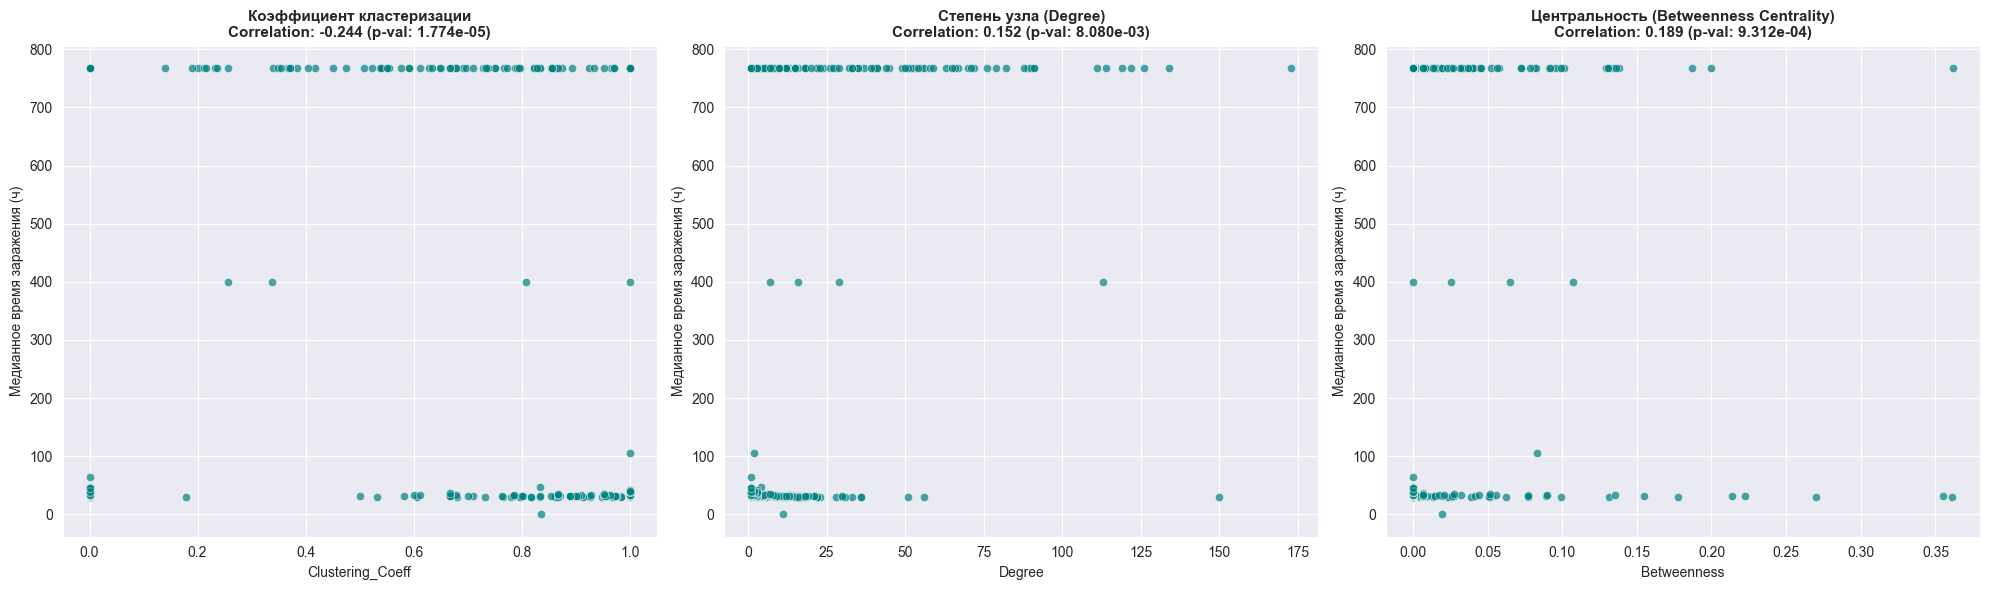

In [19]:
metrics_to_plot = ['Clustering_Coeff', 'Degree', 'Betweenness']
titles = ['Коэффициент кластеризации', 'Степень узла (Degree)', 'Центральность (Betweenness Centrality)']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, metric in enumerate(metrics_to_plot):
    corr, p_value = spearmanr(df_metrics[metric], df_metrics['Median_Infection_Time'])
    
    sns.scatterplot(
        data=df_metrics, 
        x=metric, 
        y='Median_Infection_Time', 
        ax=axes[i], 
        alpha=0.7, 
        color='teal'
    )
    axes[i].set_title(f"{titles[i]}\nCorrelation: {corr:.3f} (p-val: {p_value:.3e})", fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Медианное время заражения (ч)')
    axes[i].set_xlabel(metric)

plt.tight_layout()
plt.show()

### Выводы:

В ходе симуляции на графе авиасети (303 узла, 2683 ребра) инфекция стабилизируется на уровне 199 зараженных аэропортов (~65.6% сети). При высоком p (0.5–1.0) происходит мгновенная вспышка в первые 30 часов, а при низком p (0.01) вирус распространяется медленнее, но проникает глубже (до 80% сети). Анализ сетевых метрик показал, что коэффициент кластеризации имеет обратную связь с временем заражения (correlation: -0.244), из-за чего локально сплоченные узлы (например, OGG) заражаются быстрее всего. В то же время метрики Degree (0.152) и Betweenness (0.189) подтверждают, что крупные транзитные хабы (LAX, SFO, LAS) выступают главными местами, определяющими глобальную скорость распространения инфекции.